In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml
from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/actxdes/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)



### Update the array-like entries in the dictionary here:

In [3]:
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

# deproj = 'cib_1p8_dBeta'
# true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy'

deproj = 'cib_1p4_dBeta'
true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy'


# deproj = 'cib_1p8'
# true_y_file = 'ilc_SZ_deproj_cib_1.8_10.7_yy'

analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + f'/DESxACT/ACT_Cls/Cls_{true_y_file}_apod10arcmin_21Mar24.txt')
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = jnp.array([0.243, 0.262, 0.259, 0.301])
# analysis_dict['neff_arcmin2_SN_bins'] = jnp.array([1.476, 1.479, 1.484, 1.461])
analysis_dict['stats_for_cov'] = ['ky', 'kk']


halo_params_dict['rmax'] = 8
halo_params_dict['nr'] = 24

halo_params_dict['zmax_for_Cls'] = 1.6
halo_params_dict['zmax'] = 1.6
halo_params_dict['nz'] = 24

halo_params_dict['lg10_Mmin'] = 11.5
halo_params_dict['lg10_Mmax'] = 15.0
halo_params_dict['nM'] = 24

halo_params_dict['nk'] = 48


# sim_params_dict['cosmo']['sigma8'] = 0.59675
# sim_params_dict['cosmo']['Om0'] = 0.401

# sim_params_dict['cosmo']['sigma8'] = 0.68
# sim_params_dict['cosmo']['Om0'] = 0.3

sim_params_dict['cosmo']['sigma8'] = 0.72
sim_params_dict['cosmo']['Om0'] = 0.27

sim_params_dict['cosmo']['H0'] = 70.3

# sim_params_dict['theta_ej_0'] = 0.85
# sim_params_dict['nu_theta_ej_M'] = -0.25
# sim_params_dict['theta_co_0'] = 0.143
# sim_params_dict['nu_theta_ej_z'] = 0.3755
# sim_params_dict['mu_beta'] = 0.575
# sim_params_dict['log10_Mc0'] = 14.404
# sim_params_dict['delta_rhogas'] = 10.286
# sim_params_dict['gamma_rhogas'] = 3.122

analysis_dict['sigma_epsilon_SN_bins'] = jnp.array([0.268, 0.268, 0.268, 0.268])
analysis_dict['neff_arcmin2_SN_bins'] = jnp.array([1.795,1.5522,1.5966,1.099])

other_params_dict['alpha_ky'] = 0.842542
sim_params_dict['theta_ej_0'] =0.6786
sim_params_dict['nu_theta_ej_M'] = -0.2181
sim_params_dict['theta_co_0'] = 0.131687
sim_params_dict['nu_theta_ej_z'] = 0.281135
sim_params_dict['mu_beta'] = 1.366099
sim_params_dict['log10_Mc0'] = 14.94813
sim_params_dict['delta_rhogas'] = 11.3784
sim_params_dict['gamma_rhogas'] = 3.49110



### Do a test run of the correlation function:

In [4]:
from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)
# cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



In [5]:
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



Loaded up y-total file


In [33]:
# np.sqrt(np.diag(cov_test.covG_dict['ky_ky']['bin_4_0_4_0']))/np.sqrt(np.diag(cov_test.covNG_dict['ky_ky']['bin_4_0_4_0']))


In [7]:
deproj_all = ['cib_1p4','cib_1p6', 'cib_1p7', 'cib_1p8', 'cib_2p0', 'cib_1p4_dBeta','cib_1p6_dBeta','cib_1p7_dBeta','cib_1p8_dBeta','cib_2p0_dBeta']

df_cs = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
cov_xip_xim = df_cs['COVMAT'].data[:400,:400]
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
nbins = 4
ntheta_bin = 20
ldir = os.path.abspath(abs_path_data + '/DESxACT/measurements_shear_y/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')

for deproj in deproj_all:

    xi_all = np.zeros(480)
    theta_all = np.zeros(480)
    bin1_all = np.zeros(480)
    bin2_all = np.zeros(480)

    if deproj == 'None':
        true_y_file = 'ilc_SZ_yy'
    if deproj == 'cib_1p0':
        true_y_file = 'ilc_SZ_deproj_cib_1.0_10.7_yy'
    if deproj == 'cib_1p2':
        true_y_file = 'ilc_SZ_deproj_cib_1.2_10.7_yy'        
    if deproj == 'cib_1p4':
        true_y_file = 'ilc_SZ_deproj_cib_1.4_10.7_yy'        
    if deproj == 'cib_1p6':
        true_y_file = 'ilc_SZ_deproj_cib_1.6_10.7_yy'  
    if deproj == 'cib_1p7':
        true_y_file = 'ilc_SZ_deproj_cib_1.7_10.7_yy'                                      
    if deproj == 'cib_1p8':
        true_y_file = 'ilc_SZ_deproj_cib_1.8_10.7_yy'        
    if deproj == 'cib_2p0':
        true_y_file = 'ilc_SZ_deproj_cib_2.0_10.7_yy'                
    if deproj == 'cib_1p0_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy'        
    if deproj == 'cib_1p2_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy'
    if deproj == 'cib_1p4_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy'
    if deproj == 'cib_1p6_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy' 
    if deproj == 'cib_1p7_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'  
    if deproj == 'cib_1p8_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy'         
    if deproj == 'cib_2p0_dBeta':
        true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy' 
    analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + f'/DESxACT/ACT_Cls/Cls_{true_y_file}_apod10arcmin_21Mar24.txt')

    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
    xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)
    cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)

    ind_th_sel = np.where( (cov_test.fftcovtot_dict['ky_ky']['theta'] > 2.5) & (cov_test.fftcovtot_dict['ky_ky']['theta'] < 250.0))[0]
    cov_gty_gty = np.zeros((ntheta_bin*nbins,ntheta_bin*nbins))


    jstart = 0
    for j1 in range(nbins):
        for j2 in range(nbins):
            cov_gty_gty[ntheta_bin*j1:ntheta_bin*(j1+1),ntheta_bin*j2:ntheta_bin*(j2+1)] = cov_test.fftcovtot_dict['gty_gty']['bin_' + str(j1+1) + '_0_' + str(j2+1) + '_0'][ind_th_sel,:][:,ind_th_sel]           
            if j1 == j2:
                df = pk.load(open(ldir + '/kg_act_deprojects_' + deproj + '_vnew_wbeam_pixell_zbin_' + str(j2) + '_njk_250_healpix4096_theta_2p5_250_v27Jan24.pk','rb'))                
                rkg = df['r_kg']
                covkg = df['cov_dy']
                xikg = df['xi_kg']
                # xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = DV.xi_result_dict['gty']['yt_1bin_%d_0'%(j1+1)]['tot']
                xi_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = xikg      
                theta_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = rkg     
                bin1_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.ones_like(rkg)*j1
                bin2_all[jstart + j1*ntheta_bin:jstart + (j1+1)*ntheta_bin] = np.zeros_like(rkg)

    jstart = 80
    xi_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['VALUE']
    theta_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['ANG']
    bin1_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN1']
    bin2_all[jstart:jstart+len(df_cs['xip'].data['VALUE'])] = df_cs['xip'].data['BIN2']


    jstart = 280
    xi_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['VALUE']
    theta_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['ANG']
    bin1_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN1']
    bin2_all[jstart:jstart+len(df_cs['xim'].data['VALUE'])] = df_cs['xim'].data['BIN2']


    cov_gty_xip_mat = np.zeros((80,200))
    for jby in range(len(biny_vals)):
        by = biny_vals[jby]
        for jbk in range(len(bin1_vals)):
            b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
            val_here = cov_test.fftcovtot_dict['gty_kk']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
            cov_gty_xip_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here
            
    cov_gty_xim_mat = np.zeros((80,200))
    for jby in range(len(biny_vals)):
        by = biny_vals[jby]
        for jbk in range(len(bin1_vals)):
            b1, b2 = bin1_vals[jbk], bin2_vals[jbk]
            val_here = cov_test.fftcovtot_dict['gty_kkm']['bin_' + str(by) + '_0_' + str(b1) + '_' + str(b2)][ind_th_sel,:][:,ind_th_sel]   
            cov_gty_xim_mat[jby*20:(jby+1)*20,jbk*20:(jbk+1)*20] = val_here


    cov_total = np.zeros((480, 480))
    # assemble the pieces:
    cov_total[0:80, 0:80] = cov_gty_gty
    cov_total[0:80, 80:280] = cov_gty_xip_mat
    cov_total[0:80, 280:480] = cov_gty_xim_mat
    cov_total[80:280, 0:80] = cov_gty_xip_mat.T
    cov_total[280:480, 0:80] = cov_gty_xim_mat.T
    cov_total[80:480, 80:480] = cov_xip_xim

    saved = {'theta_all':theta_all, 'xi_all':xi_all, 'cov_total':cov_total, 'bin1_all':bin1_all, 'bin2_all':bin2_all}
    SNR = np.sqrt(np.dot(xi_all, np.dot(np.linalg.inv(cov_total), xi_all)))
    SNR_gty_only = np.sqrt(np.dot(xi_all[0:80], np.dot(np.linalg.inv(cov_gty_gty), xi_all[0:80])))
    print('for deproj =', deproj, ', SNR =', np.round(SNR, 2), 
        ', SNR gty-only =', np.round(SNR_gty_only, 2), 
        ', cond-cov =', np.round(np.linalg.cond(cov_total), 3))
    pk.dump(saved, open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk','wb'))



Loaded up y-total file
for deproj = cib_1p4 , SNR = 48.61 , SNR gty-only = 22.63 , cond-cov = 4339283458197.17
Loaded up y-total file
for deproj = cib_1p6 , SNR = 48.92 , SNR gty-only = 23.67 , cond-cov = 5178039088844.86
Loaded up y-total file
for deproj = cib_1p7 , SNR = 49.11 , SNR gty-only = 24.28 , cond-cov = 5674627046971.47
Loaded up y-total file
for deproj = cib_1p8 , SNR = 49.31 , SNR gty-only = 24.9 , cond-cov = 6178522614962.622
Loaded up y-total file
for deproj = cib_2p0 , SNR = 49.73 , SNR gty-only = 26.08 , cond-cov = 6658312727444.245
Loaded up y-total file
for deproj = cib_1p4_dBeta , SNR = 48.04 , SNR gty-only = 20.96 , cond-cov = 1004225785547.664
Loaded up y-total file
for deproj = cib_1p6_dBeta , SNR = 48.23 , SNR gty-only = 21.46 , cond-cov = 1322789274145.724
Loaded up y-total file
for deproj = cib_1p7_dBeta , SNR = 48.32 , SNR gty-only = 21.71 , cond-cov = 1508417932123.083
Loaded up y-total file
for deproj = cib_1p8_dBeta , SNR = 48.39 , SNR gty-only = 21.91 , c

In [27]:
# cov_test.theta_out_arcmin
# cov_test.fftcovtot_dict['ky_ky']['theta']
# ind_th_sel

array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
       31, 32, 33])

/tmp/ipykernel_2228663/1489983657.py:3: RuntimeWarning: invalid value encountered in log
  corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')


Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

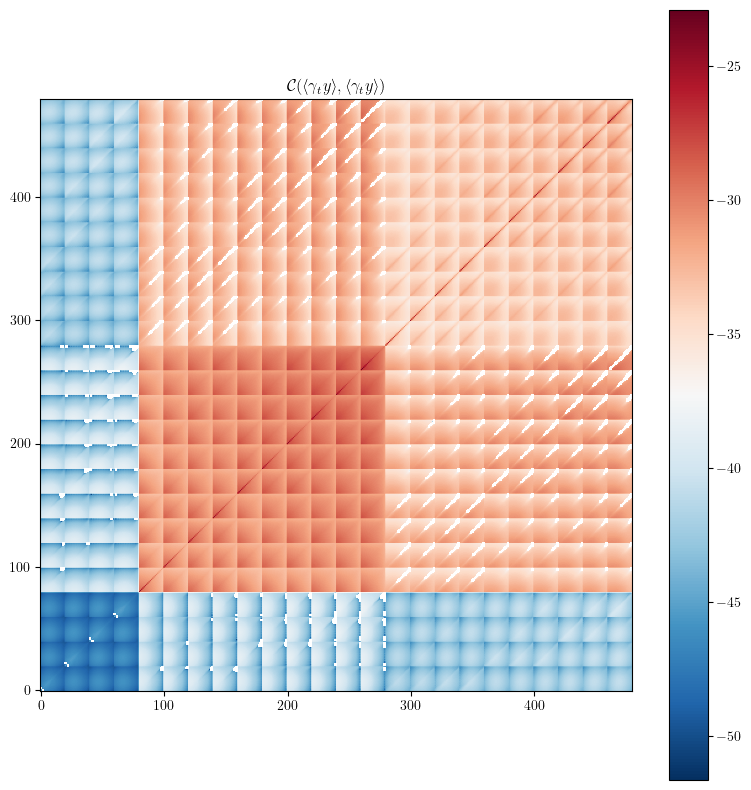

In [21]:
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

corr = ax.imshow((np.log((cov_total))), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



/tmp/ipykernel_2228663/4172509505.py:3: RuntimeWarning: invalid value encountered in log
  corr = ax.imshow((np.log((cov_total[0:80,0:80]))), origin='lower', cmap='RdBu_r')


Text(0.5, 1.0, '$\\mathcal{C}(\\langle \\gamma_t y \\rangle, \\langle \\gamma_t y \\rangle)$')

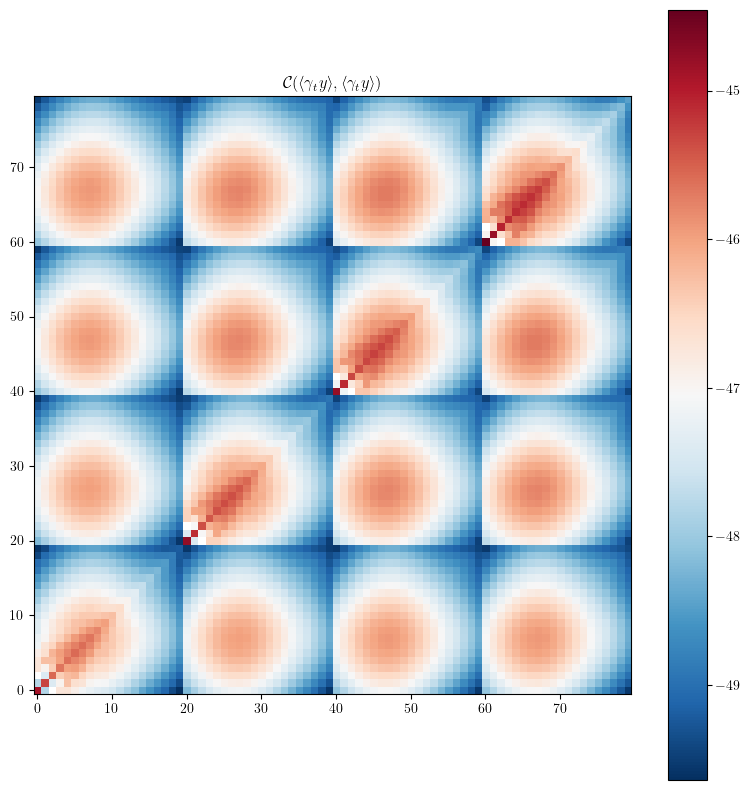

In [23]:
fig, ax = pl.subplots(1, 1, figsize=(8, 8))

corr = ax.imshow((np.log((cov_total[0:80,0:80]))), origin='lower', cmap='RdBu_r')
fig.colorbar(corr, ax=ax)
fig.tight_layout()
ax.set_title(r'$\mathcal{C}(\langle \gamma_t y \rangle, \langle \gamma_t y \rangle)$')



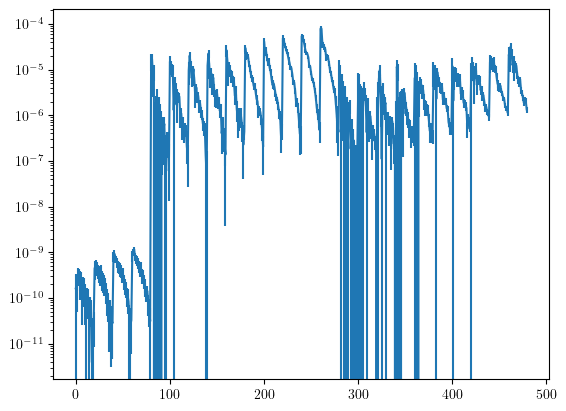

In [22]:
pl.figure()
pl.errorbar(np.arange(480), xi_all, yerr = np.sqrt(np.diag(cov_total)))
pl.yscale('log')



In [5]:
#     # pk.dump(saved, open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk','wb'))
# # saved = {'theta_all':theta_all, 'xi_all':xi_all, 'cov_total':cov_total, 'bin1_all':bin1_all, 'bin2_all':bin2_all}
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy' 
# df = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk','rb'))
# theta_all = df['theta_all']
# xi_all = df['xi_all']
# cov_total = df['cov_total']
# bin1_all = df['bin1_all']
# bin2_all = df['bin2_all']



In [55]:
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# probe = 'xip_xim' 
probe = 'gty'
# probe = 'all'



if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

P_total = jnp.linalg.inv(cov_total)



In [56]:
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )


In [57]:
df_cs = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])

# index_gty = {}
index_gty = []
for js in range(80):
    # index_gty[js] = [js%20 ,js//20]
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
# index_xip = {}
index_xip = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xip[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]
    index_xip.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xip = jnp.array(index_xip)
# index_xim = {}
index_xim = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xim[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]   
    index_xim.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xim = jnp.array(index_xim)



In [73]:
prior_min_all_dict = {}
prior_max_all_dict = {}
prior_min_all_dict['Om0'] = 0.1
prior_max_all_dict['Om0'] = 0.5
prior_min_all_dict['Ob0'] = 0.03
prior_max_all_dict['Ob0'] = 0.07
prior_min_all_dict['h'] = 0.5
prior_max_all_dict['h'] = 0.9
prior_min_all_dict['ns'] = 0.8
prior_max_all_dict['ns'] = 1.2
prior_min_all_dict['sigma8'] = 0.6
prior_max_all_dict['sigma8'] = 1.0

# sim_params_dict['theta_ej_0'] = 1.0
# sim_params_dict['nu_theta_ej_M'] = -0.2
# sim_params_dict['mu_beta'] = 0.2
# sim_params_dict['log10_Mc0'] = 14.0
# sim_params_dict['delta_rhogas'] = 6.0
# sim_params_dict['gamma_rhogas'] = 2.0

prior_min_all_dict['theta_co_0'] = 0.001
prior_max_all_dict['theta_co_0'] = 0.2
prior_min_all_dict['theta_ej_0'] = 0.5
prior_max_all_dict['theta_ej_0'] = 4.0
prior_min_all_dict['nu_theta_ej_M'] = -1.0
prior_max_all_dict['nu_theta_ej_M'] = 0.0
prior_min_all_dict['nu_theta_ej_z'] = -1.0
prior_max_all_dict['nu_theta_ej_z'] = 1.0
prior_min_all_dict['mu_beta'] = 0.1
prior_max_all_dict['mu_beta'] = 2.0
prior_min_all_dict['log10_Mc0'] = 12.0
prior_max_all_dict['log10_Mc0'] = 16.0
prior_min_all_dict['delta_rhogas'] = 3.0
prior_max_all_dict['delta_rhogas'] = 14.0
prior_min_all_dict['gamma_rhogas'] = 1.0
prior_max_all_dict['gamma_rhogas'] = 6.0
prior_min_all_dict['alpha_ky'] = 0.8
prior_max_all_dict['alpha_ky'] = 1.2


prior_min_all_dict['alpha_nt'] = 0.0
prior_max_all_dict['alpha_nt'] = 0.4
# prior_min_all_dict['mu_beta'] = 0.1
# prior_max_all_dict['mu_beta'] = 1.0



prior_min_all_dict['A_IA'] = -3.0
prior_max_all_dict['A_IA'] = 3.0
prior_min_all_dict['eta_IA'] = -2.0
prior_max_all_dict['eta_IA'] = 2.0

prior_mu_all_dict = {}
prior_sig_all_dict = {}
prior_mu_all_dict['Delta_z_bias_bin1'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin1'] = 1.8e-2
prior_mu_all_dict['Delta_z_bias_bin2'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin2'] = 1.5e-2
prior_mu_all_dict['Delta_z_bias_bin3'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin3'] = 1.1e-2
prior_mu_all_dict['Delta_z_bias_bin4'] = 0.0
prior_sig_all_dict['Delta_z_bias_bin4'] = 1.7e-2

prior_mu_all_dict['mult_shear_bias_bin1'] = -6e-3
prior_sig_all_dict['mult_shear_bias_bin1'] = 9e-3
prior_mu_all_dict['mult_shear_bias_bin2'] = -2e-2
prior_sig_all_dict['mult_shear_bias_bin2'] = 8e-3
prior_mu_all_dict['mult_shear_bias_bin3'] = -2.4e-2
prior_sig_all_dict['mult_shear_bias_bin3'] = 8e-3
prior_mu_all_dict['mult_shear_bias_bin4'] = -3.7e-2
prior_sig_all_dict['mult_shear_bias_bin4'] = 8e-3

prior_delta_z_mu_all = jnp.array([prior_mu_all_dict['Delta_z_bias_bin1'], prior_mu_all_dict['Delta_z_bias_bin2'], prior_mu_all_dict['Delta_z_bias_bin3'], prior_mu_all_dict['Delta_z_bias_bin4']])
prior_delta_z_sig_all = jnp.array([prior_sig_all_dict['Delta_z_bias_bin1'], prior_sig_all_dict['Delta_z_bias_bin2'], prior_sig_all_dict['Delta_z_bias_bin3'], prior_sig_all_dict['Delta_z_bias_bin4']])

prior_mult_shear_mu_all = jnp.array([prior_mu_all_dict['mult_shear_bias_bin1'], prior_mu_all_dict['mult_shear_bias_bin2'], prior_mu_all_dict['mult_shear_bias_bin3'], prior_mu_all_dict['mult_shear_bias_bin4']])
prior_mult_shear_sig_all = jnp.array([prior_sig_all_dict['mult_shear_bias_bin1'], prior_sig_all_dict['mult_shear_bias_bin2'], prior_sig_all_dict['mult_shear_bias_bin3'], prior_sig_all_dict['mult_shear_bias_bin4']])




In [74]:
# cosmo_params_vary_names = ['Om0', 'sigma8', 'Ob0', 'h', 'ns']
cosmo_params_vary_names = []
sims_params_vary_names = ['theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z', 'theta_co_0', 'mu_beta', 'log10_Mc0', 'delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names = []
# cosmo_params_vary_names = []
# IA_params_vary_names = ['A_IA', 'eta_IA']
# IA_params_vary_names = ['eta_IA']
IA_params_vary_names = []

other_params_vary_names = ['alpha_ky']

# mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4'] 
# Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4']

custom_init_values_dict = {'A_IA': 0.1, 'eta_IA': 0.01, 'mu_beta': 0.6, 'nu_theta_ej_M': -0.15, 'nu_theta_ej_z': 0.1}






In [75]:
from get_Xis import get_xi
import numpyro
import copy

def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    if len(cosmo_params_vary_names) > 0:
        for jp in range(len(cosmo_params_vary_names)):
            if cosmo_params_vary_names[jp] == 'h':
                fac = 100.
                cosmo_name = 'H0'
            else:
                fac = 1.
                cosmo_name = cosmo_params_vary_names[jp]
            prior_min_jp = prior_min_all_dict[cosmo_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[cosmo_params_vary_names[jp]]
            sim_params_dict_vary['cosmo'][cosmo_name] = fac * Uniform(cosmo_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(sims_params_vary_names) > 0:
        for jp in range(len(sims_params_vary_names)):
            prior_min_jp = prior_min_all_dict[sims_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[sims_params_vary_names[jp]]
            sim_params_dict_vary[sims_params_vary_names[jp]] = Uniform(sims_params_vary_names[jp], prior_min_jp, prior_max_jp)
    
    # if len(IA_params_vary_names) > 0:
    #     for jp in range(len(IA_params_vary_names)):
    #         prior_min_jp = prior_min_all_dict[IA_params_vary_names[jp]]
    #         prior_max_jp = prior_max_all_dict[IA_params_vary_names[jp]]
    #         other_params_dict_vary[IA_params_vary_names[jp]] = Uniform(IA_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(other_params_vary_names) > 0:
        for jp in range(len(other_params_vary_names)):
            prior_min_jp = prior_min_all_dict[other_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[other_params_vary_names[jp]]
            other_params_dict_vary[other_params_vary_names[jp]] = Uniform(other_params_vary_names[jp], prior_min_jp, prior_max_jp)

    # if len(prior_delta_z_mu_all) > 0:
    #     Delta_z_bias_array = numpyro.sample('Delta_z_bias_array', dist.Normal(prior_delta_z_mu_all, prior_delta_z_sig_all)) 
    #     other_params_dict_vary['Delta_z_bias_array'] = Delta_z_bias_array
    
    # if len(prior_mult_shear_mu_all) > 0:
    #     mult_shear_bias_array = numpyro.sample('mult_shear_bias_array', dist.Normal(prior_mult_shear_mu_all, prior_mult_shear_sig_all))
    #     other_params_dict_vary['mult_shear_bias_array'] = mult_shear_bias_array
        
    get_corrfunc_BCMP_test = get_xi(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    def get_gty_from_index(index):
        index_val = index_gty[index]
        return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

    def get_xip_from_index(index):
        index_val = index_xip[index]
        return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

    def get_xim_from_index(index):
        index_val = index_xim[index]
        return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

    gty_val = vmap(get_gty_from_index)(np.arange(80))
    xip_val = vmap(get_xip_from_index)(np.arange(200))
    xim_val = vmap(get_xim_from_index)(np.arange(200))

    if probe == 'xip_xim':
        mu = jnp.concatenate([xip_val, xim_val])
    elif probe == 'gty':
        mu = gty_val
    else:
        mu = jnp.concatenate([gty_val, xip_val, xim_val])
    # print(mu.shape, P_total.shape, cov_total.shape)
    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                        precision_matrix=P_total,
                                                        covariance_matrix=cov_total))






In [76]:
import numpyro
numpyro.enable_x64()
numpyro.set_platform("gpu")
# numpyro.set_host_device_count(4)
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations
observed_model = condition(model, {'cl': data_vec})



In [77]:
import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)



In [78]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=5e-1, 
                            init_strategy=numpyro.infer.init_to_sample,
                            # init_strategy=numpyro.infer.init_to_value(values=custom_init_values_dict),                            
                            dense_mass=True,
                            max_tree_depth=4,
                            adapt_mass_matrix=True, 
                            adapt_step_size=True,
                            forward_mode_differentiation=False)




In [79]:
mcmc = numpyro.infer.MCMC(nuts_kernel, 
                          num_warmup=500, 
                          num_samples=500,
                          num_chains=16,
                          chain_method='vectorized',
                        #   chain_method='sequential',                          
                          progress_bar=True,
                          jit_model_args=True)




In [80]:
import jax

# mcmc.run(jax.random.PRNGKey(42), collect_diagnostics=True)
mcmc.run(jax.random.PRNGKey(42), extra_fields=("potential_energy",))
diagnostics = mcmc.get_extra_fields()




sample: 100%|██████████| 1000/1000 [32:54<00:00,  1.97s/it]


In [81]:
# df = mcmc.get_samples()
df = {**mcmc.get_samples(), **mcmc.get_extra_fields()}







In [82]:
# df
# mcmc.items()
# mcmc.get_extra_fields()

(7600, 9)
Removed no burn in
1.0157843780133475 269.98986928489126


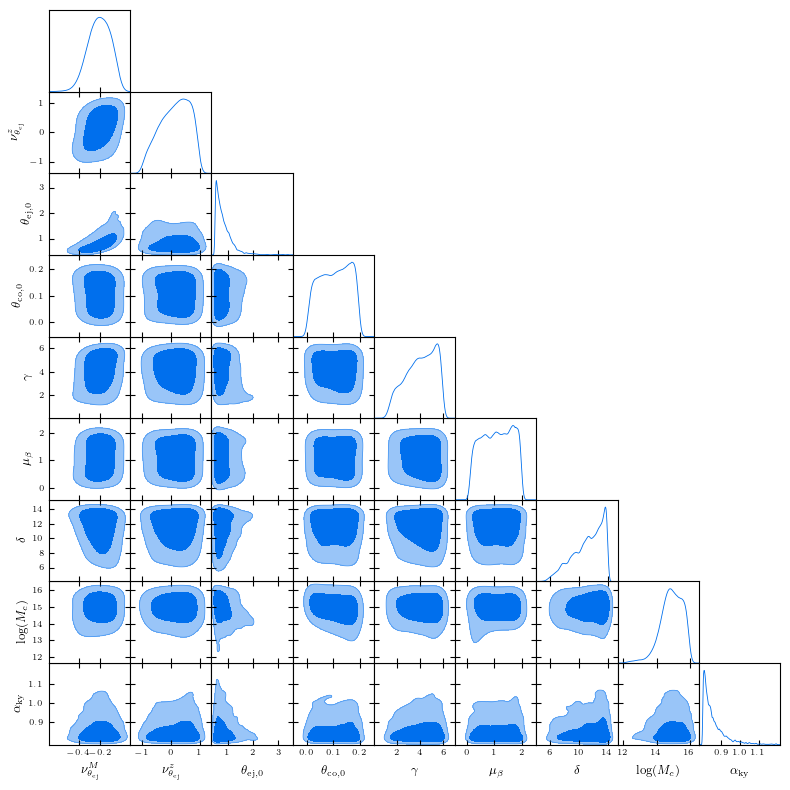

In [83]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('theta_ej_0')
# ind_thetaejM = keys.index('nu_theta_ej_M')
# ind_Om = keys.index('Om0')
# samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

# samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
# keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'
labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
 'log10_Mc0':r'$\log(M_c)$',
    'delta_rhogas':r'$\delta$',
    'gamma_rhogas':r'$\gamma$',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
nchains = 16
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# # ind_del = np.array([4, 10])
# # ind_del = np.array([3])
# # ind_del = np.array([1,2,4,7])
# # ind_del = np.array([0,7,8,9,10])
# ind_del = [0]
# # ind_del = [3,5,8]
# # ind_del = [0,3,4,5,6,7,8,9,10,11]
# if len(ind_del) > 0:
#     samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
    # samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape)

# saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
# savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

from numpyro.diagnostics import gelman_rubin, effective_sample_size
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
ess = effective_sample_size(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
print(gr, ess)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
params = ['nu_theta_ej_M','nu_theta_ej_z','theta_ej_0','theta_co_0','gamma_rhogas', 'mu_beta', 'delta_rhogas','log10_Mc0', 'alpha_ky']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
# save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'test_vary_thetaej_mubeta_all_npf_response_response.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()



In [84]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
# ind_sigma8 = keys.index('sigma8')
# ind_Om = keys.index('Om0')
# samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

# samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
# keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestift = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestift[key] = samps[map_ind, jk]


alpha_ky 0.8425422758307537
delta_rhogas 11.378482219643109
gamma_rhogas 3.491104780931271
log10_Mc0 14.94813556950639
mu_beta 1.3660991486165877
nu_theta_ej_M -0.21813685749071865
nu_theta_ej_z 0.28113582570081813
theta_co_0 0.13168764430111968
theta_ej_0 0.6786694968663725
potential_energy -1742.713754338606


In [30]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck18')


In [43]:
neff = (-2*cosmo.sigma(5.8, derivative=True)) - 3
print(neff)


-1.7502751486774717


In [42]:
print(2.93*(1.77**neff))


1.0785646314693638


In [39]:
cosmo.sigma(5.8)


1.000273744731806